# Analysis

## Tree

In [ ]:
import os

def print_tree(start_path, max_depth=3):
    start_path = os.path.abspath(start_path)

    for root, dirs, files in os.walk(start_path):
        level = root.replace(start_path, "").count(os.sep)
        
        if level > max_depth:
            continue
        
        indent = "│   " * level
        print(f"{indent}├── {os.path.basename(root)}/")
        
        sub_indent = "│   " * (level + 1)
        for f in files:
            print(f"{sub_indent}├── {f}")

# 현재 위치 기준 실행
print_tree(".", max_depth=3)

## setup

In [7]:
import os
import json
import matplotlib.pyplot as plt

In [31]:
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, 'data')
MODEL_DIR = os.path.join(BASE_DIR, 'models')
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')

## RQ1
### Graph

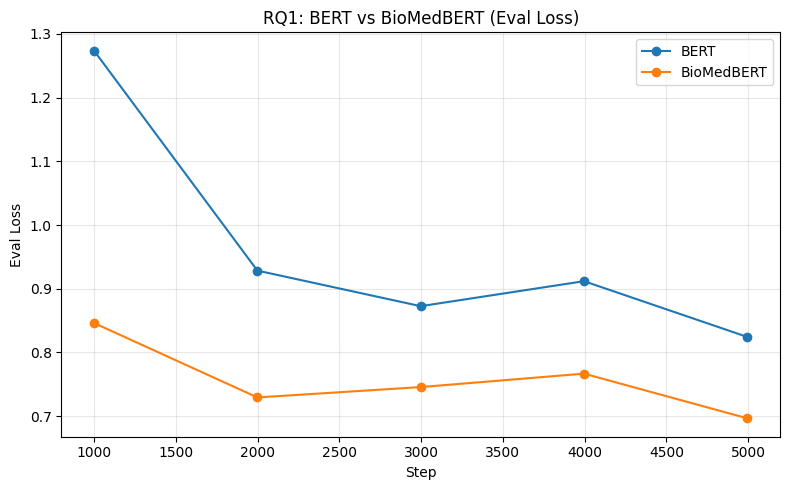

Saved to: c:\Users\Minkyu Ham\Desktop\stat359\student\final_project\clinical_note_icd_llm\outputs\rq1_eval_loss.png


In [28]:
import os
import json
import matplotlib.pyplot as plt

# 경로
base_path = os.path.join(OUTPUT_DIR, "base_bert_ce", "trainer_log_history.json")
biomed_path = os.path.join(OUTPUT_DIR, "biomed_bert_ce", "trainer_log_history.json")

# json 로드
with open(base_path, "r") as f:
    base_logs = json.load(f)

with open(biomed_path, "r") as f:
    biomed_logs = json.load(f)

# step 중복 제거 (같은 step이면 마지막 값 사용)
base_dict = {}
for log in base_logs:
    if "eval_loss" in log:
        base_dict[log["step"]] = log["eval_loss"]

biomed_dict = {}
for log in biomed_logs:
    if "eval_loss" in log:
        biomed_dict[log["step"]] = log["eval_loss"]

# 정렬
base_steps = sorted(base_dict.keys())
base_loss = [base_dict[s] for s in base_steps]

biomed_steps = sorted(biomed_dict.keys())
biomed_loss = [biomed_dict[s] for s in biomed_steps]

# 그래프
plt.figure(figsize=(8, 5))

plt.plot(base_steps, base_loss, marker='o', label="BERT")
plt.plot(biomed_steps, biomed_loss, marker='o', label="BioMedBERT")

plt.title("RQ1: BERT vs BioMedBERT (Eval Loss)")
plt.xlabel("Step")
plt.ylabel("Eval Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

# 저장 경로
save_path = os.path.join(OUTPUT_DIR, "rq1_eval_loss.png")

# 저장
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved to: {save_path}")

### Table

In [25]:
import os
import json
import pandas as pd

# 경로
base_path = os.path.join(OUTPUT_DIR, "base_bert_ce", "test_metrics.json")
biomed_path = os.path.join(OUTPUT_DIR, "biomed_bert_ce", "test_metrics.json")

# 로드
with open(base_path, "r") as f:
    base_metrics = json.load(f)

with open(biomed_path, "r") as f:
    biomed_metrics = json.load(f)

# 표 생성
data = [
    {
        "Model": "BERT",
        "Macro F1": base_metrics["eval_macro_f1"],
        "Top-1": base_metrics["eval_accuracy"],   # ← 여기 중요
        "Top-3": base_metrics["eval_hit@3"],
        "Top-5": base_metrics["eval_hit@5"],
    },
    {
        "Model": "BioMedBERT",
        "Macro F1": biomed_metrics["eval_macro_f1"],
        "Top-1": biomed_metrics["eval_accuracy"],
        "Top-3": biomed_metrics["eval_hit@3"],
        "Top-5": biomed_metrics["eval_hit@5"],
    }
]

df = pd.DataFrame(data).round(4)

print("\n   ========= Test Evaluation Results ==========")
df


   ========= Test Evaluation Results ==========


,Model,Macro F1,Top-1,Top-3,Top-5
0,BERT,0.7797,0.7808,0.9369,0.958
1,BioMedBERT,0.8259,0.8278,0.9600,0.975


### Tokenizer

In [33]:
import os
import pandas as pd
from transformers import AutoTokenizer

# 1. tokenizer 로드
bert_tokenizer = AutoTokenizer.from_pretrained(
    os.path.join(MODEL_DIR, "base_bert_ce")
)

biomed_tokenizer = AutoTokenizer.from_pretrained(
    os.path.join(MODEL_DIR, "biomed_bert_ce")
)

# 2. 예시 데이터 불러오기
test_df = pd.read_csv(os.path.join(DATA_DIR, "test_30_999.csv"))

# 3. 예시 문장 하나 선택
sample_text = test_df.loc[0, "filtered_text"]   # 컬럼명이 text가 아니면 바꿔야 함

print("=== Sample Text ===")
print(sample_text[:1000])  # 너무 길면 앞부분만 출력
print()

# 4. 토큰화
bert_tokens = bert_tokenizer.tokenize(sample_text)
biomed_tokens = biomed_tokenizer.tokenize(sample_text)

# 5. 결과 출력
print("=== BERT Tokens (first 50) ===")
print(bert_tokens[:50])
print("Token count:", len(bert_tokens))
print()

print("=== BioMedBERT Tokens (first 50) ===")
print(biomed_tokens[:50])
print("Token count:", len(biomed_tokens))
print()

comparison_df = pd.DataFrame({
    "Model": ["BERT", "BioMedBERT"],
    "Token Count": [len(bert_tokens), len(biomed_tokens)],
    "First 20 Tokens": [
        " ".join(bert_tokens[:20]),
        " ".join(biomed_tokens[:20]),
    ]
})

comparison_df

=== Sample Text ===
NSTEMI, status post bilateral ureteral stenting.

Patient is a male with a history of CAD, HTN, HLD, nephrolithiasis, and mild cognitive delay admitted for E. Coli urosepsis. During admission, CT abdomen/pelvis revealed bilateral hydronephrosis, bilateral nephrolithiasis, and left distal ureteral calculi. He underwent bilateral ureteral stenting. Blood cultures grew E. Coli, and he was treated with antibiotics. He had positive troponins (peak 1.27) without chest pain. Cardiac catheterization revealed 3-vessel disease. He underwent CABG x3 (LIMA-LAD, SVG-PDA-PLV) on [MASKED].

Admitted for E. Coli urosepsis, s/p bilateral ureteral stenting. Evaluated for CAD, found to have 3-vessel disease. Underwent CABG x3. Post-operatively developed anemia (Hgb 8.0-9.0). Blood cultures grew Enterococcus sp.; antibiotics adjusted. Foley replaced for urinary retention. Managed for hypertension, hyperlipidemia, and renal insufficiency. Discharged to extended care facility.

=== BERT 

,Model,Token Count,First 20 Tokens
0,BERT,258,"ns ##tem ##i , status post bilateral ur ##eter..."
1,BioMedBERT,220,"ns ##te ##mi , status post bilateral ureteral ..."


In [35]:
from transformers import AutoTokenizer
import os
import pandas as pd

# tokenizer 로드
bert_tokenizer = AutoTokenizer.from_pretrained(
    os.path.join(MODEL_DIR, "base_bert_ce")
)

biomed_tokenizer = AutoTokenizer.from_pretrained(
    os.path.join(MODEL_DIR, "biomed_bert_ce")
)

# 비교할 clinical terms
terms = [
    "NSTEMI",
    "ureteral",
    "stenting",
    "HTN",
    "nephrolithiasis",
    "urosepsis",
    "troponins",
    "catheterization",
    "CABG",
    "hydronephrosis",
]

rows = []

for term in terms:
    bert_split = bert_tokenizer.tokenize(term)
    biomed_split = biomed_tokenizer.tokenize(term)

    rows.append({
        "Term": term,
        "BERT Tokens": " / ".join(bert_split),
        "BERT Count": len(bert_split),
        "BioMedBERT Tokens": " / ".join(biomed_split),
        "BioMedBERT Count": len(biomed_split),
    })

token_compare_df = pd.DataFrame(rows)
token_compare_df

,Term,BERT Tokens,BERT Count,BioMedBERT Tokens,BioMedBERT Count
0,NSTEMI,ns / ##tem / ##i,3,ns / ##te / ##mi,3
1,ureteral,ur / ##eter / ##al,3,ureteral,1
2,stenting,ste / ##nting,2,stenting,1
3,HTN,h / ##t / ##n,3,htn,1
4,nephrolithiasis,ne / ##ph / ##rol / ##ith / ##ias / ##is,6,neph / ##rol / ##ithiasis,3
5,urosepsis,ur / ##ose / ##psis,3,uro / ##se / ##ps / ##is,4
6,troponins,tr / ##op / ##oni / ##ns,4,troponin / ##s,2
7,catheterization,cat / ##het / ##eri / ##zation,4,catheterization,1
8,CABG,cab / ##g,2,cabg,1
9,hydronephrosis,hydro / ##ne / ##ph / ##rosis,4,hydro / ##ne / ##ph / ##rosis,4


In [36]:
print("BERT avg token length:", len(bert_tokens))
print("BioMedBERT avg token length:", len(biomed_tokens))

BERT avg token length: 258
BioMedBERT avg token length: 220


## RQ2
### Graph

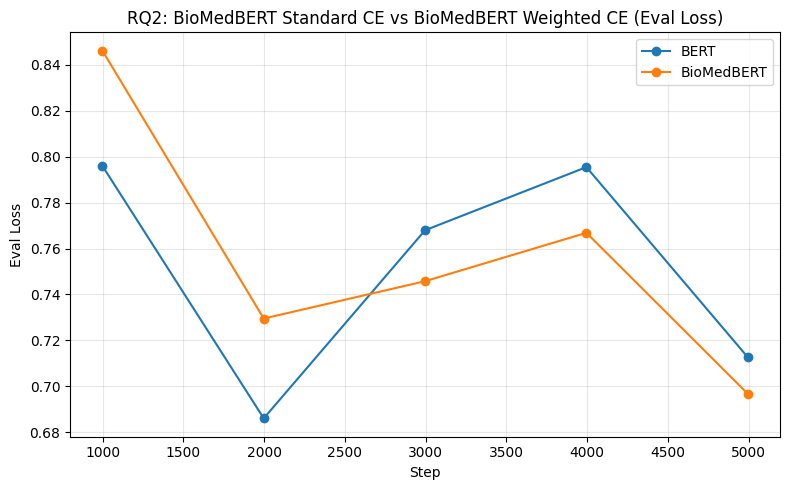

Saved to: c:\Users\Minkyu Ham\Desktop\stat359\student\final_project\clinical_note_icd_llm\outputs\rq2_eval_loss.png


In [29]:
import os
import json
import matplotlib.pyplot as plt

# 경로
biomed_standard_path = os.path.join(OUTPUT_DIR, "biomed_bert_ce", "trainer_log_history.json")
biomed_weighted_path = os.path.join(OUTPUT_DIR, "biomed_bert_weighted_ce", "trainer_log_history.json")

# json 로드
with open(biomed_weighted_path, "r") as f:
    base_logs = json.load(f)

with open(biomed_standard_path, "r") as f:
    biomed_logs = json.load(f)

# step 중복 제거 (같은 step이면 마지막 값 사용)
base_dict = {}
for log in base_logs:
    if "eval_loss" in log:
        base_dict[log["step"]] = log["eval_loss"]

biomed_dict = {}
for log in biomed_logs:
    if "eval_loss" in log:
        biomed_dict[log["step"]] = log["eval_loss"]

# 정렬
base_steps = sorted(base_dict.keys())
base_loss = [base_dict[s] for s in base_steps]

biomed_steps = sorted(biomed_dict.keys())
biomed_loss = [biomed_dict[s] for s in biomed_steps]

# 그래프
plt.figure(figsize=(8, 5))

plt.plot(base_steps, base_loss, marker='o', label="BERT")
plt.plot(biomed_steps, biomed_loss, marker='o', label="BioMedBERT")

plt.title("RQ2: BioMedBERT Standard CE vs BioMedBERT Weighted CE (Eval Loss)")
plt.xlabel("Step")
plt.ylabel("Eval Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

# 저장 경로
save_path = os.path.join(OUTPUT_DIR, "rq2_eval_loss.png")

# 저장
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved to: {save_path}")

### Table

In [30]:
import os
import json
import pandas as pd

# 경로
biomed_standard_path = os.path.join(OUTPUT_DIR, "biomed_bert_ce", "test_metrics.json")
biomed_weighted_path = os.path.join(OUTPUT_DIR, "biomed_bert_weighted_ce", "test_metrics.json")

# json 로드
with open(biomed_weighted_path, "r") as f:
    base_metrics = json.load(f)

with open(biomed_standard_path, "r") as f:
    biomed_metrics = json.load(f)

# 표 생성
data = [
    {
        "Model": "BERT",
        "Macro F1": base_metrics["eval_macro_f1"],
        "Top-1": base_metrics["eval_accuracy"],   # ← 여기 중요
        "Top-3": base_metrics["eval_hit@3"],
        "Top-5": base_metrics["eval_hit@5"],
    },
    {
        "Model": "BioMedBERT",
        "Macro F1": biomed_metrics["eval_macro_f1"],
        "Top-1": biomed_metrics["eval_accuracy"],
        "Top-3": biomed_metrics["eval_hit@3"],
        "Top-5": biomed_metrics["eval_hit@5"],
    }
]

df = pd.DataFrame(data).round(4)

print("\n   ========= Test Evaluation Results ==========")
df


   ========= Test Evaluation Results ==========


,Model,Macro F1,Top-1,Top-3,Top-5
0,BERT,0.8231,0.8248,0.9469,0.969
1,BioMedBERT,0.8259,0.8278,0.9600,0.975


## Class-wise F1

['reformulation', 'icd_code', 'filtered_text', 'major_code', 'labels']
texts: 999
y_true shape: (999,)


,label,precision,recall,f1,support
0,A41,0.833333,0.817308,0.825243,104.0
5,I21,0.850000,0.894737,0.871795,57.0
29,Z51,0.980769,0.980769,0.980769,52.0
6,I25,0.882353,0.900000,0.891089,50.0
4,I13,0.641509,0.739130,0.686869,46.0
10,I63,0.954545,0.976744,0.965517,43.0
1,E11,0.846154,0.846154,0.846154,39.0
21,N17,0.862069,0.675676,0.757576,37.0
15,K80,0.966667,0.828571,0.892308,35.0
27,T81,0.785714,0.666667,0.721311,33.0


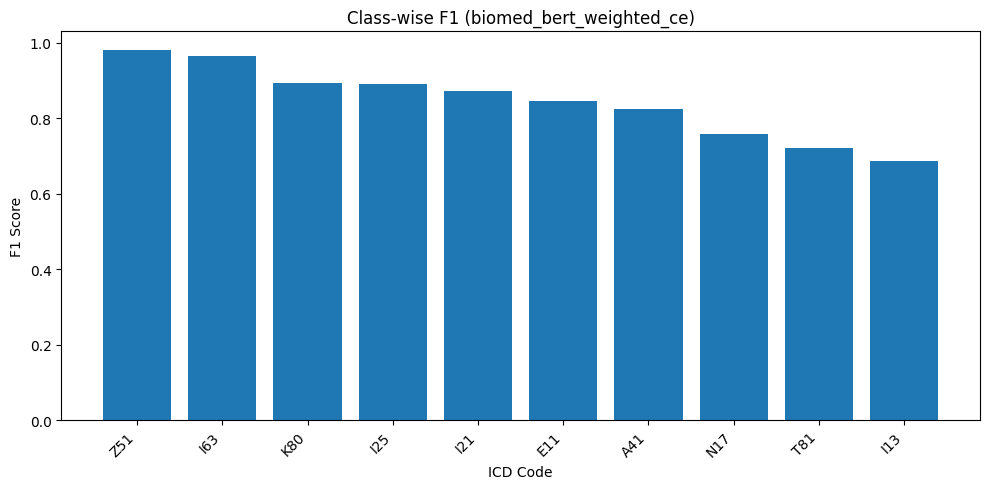

Saved to: c:\Users\Minkyu Ham\Desktop\stat359\student\final_project\clinical_note_icd_llm\outputs\biomed_bert_weighted_ce_classwise_f1_top10.png


In [45]:
import os
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report

# ===== 설정 =====
MODEL_NAME = "biomed_bert_weighted_ce"
MODEL_PATH = os.path.join(MODEL_DIR, MODEL_NAME)
TEST_PATH = os.path.join(DATA_DIR, "test_30_999.csv")
ID2LABEL_PATH = os.path.join(DATA_DIR, "id2label_top30.json")

# ===== 데이터 로드 =====
test_df = pd.read_csv(TEST_PATH)

with open(ID2LABEL_PATH, "r", encoding="utf-8") as f:
    id2label = json.load(f)

texts = test_df["filtered_text"].fillna("").tolist()
y_true = test_df["labels"].astype(int).to_numpy()

print(test_df.columns.tolist())
print("texts:", len(texts))
print("y_true shape:", y_true.shape)

# ===== 모델 로드 =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH).to(device)
model.eval()

# ===== 예측 =====
all_preds = []

with torch.no_grad():
    for i in range(0, len(texts), 8):
        batch_texts = texts[i:i+8]
        enc = tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=512,
            return_tensors="pt"
        ).to(device)

        logits = model(**enc).logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)

y_pred = np.array(all_preds)

# ===== class-wise report =====
report = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(id2label))),
    target_names=[id2label[str(i)] for i in range(len(id2label))],
    output_dict=True,
    zero_division=0
)

classwise_df = pd.DataFrame(report).T.iloc[:-3].reset_index()
classwise_df.columns = ["label", "precision", "recall", "f1", "support"]
classwise_df = classwise_df.sort_values("support", ascending=False)

display(classwise_df)

# ===== 그래프 =====
plot_df = classwise_df.head(10).sort_values("f1", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["label"], plot_df["f1"])
plt.title(f"Class-wise F1 ({MODEL_NAME})")
plt.xlabel("ICD Code")
plt.ylabel("F1 Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_classwise_f1_top10.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {save_path}")

## Confusion Metrics

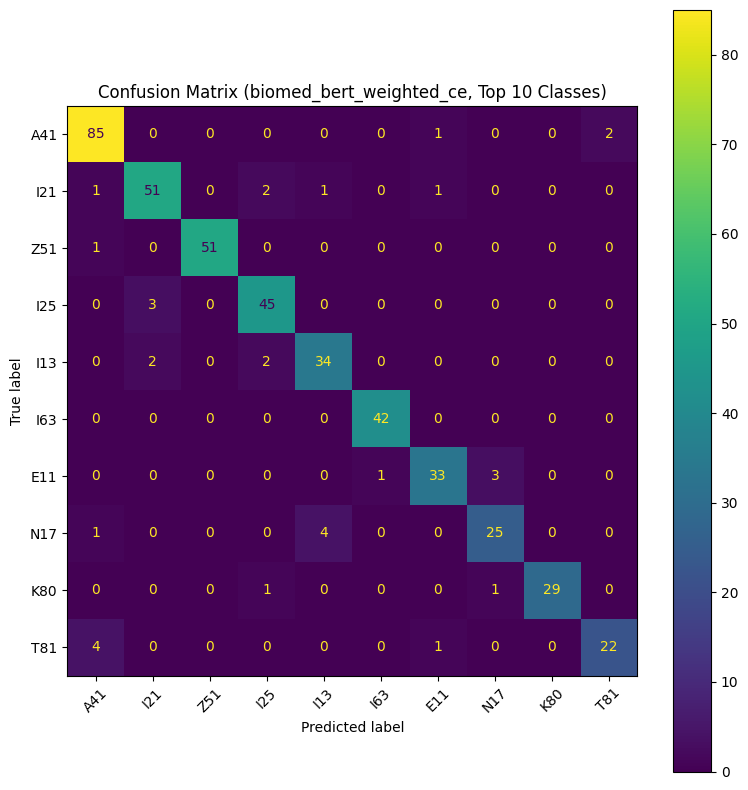

Saved to: c:\Users\Minkyu Ham\Desktop\stat359\student\final_project\clinical_note_icd_llm\outputs\biomed_bert_weighted_ce_confusion_matrix_top10.png


In [42]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

top_df = classwise_df.sort_values("support", ascending=False).head(10)
top_codes = top_df["label"].tolist()

code_to_id = {id2label[str(i)]: i for i in range(len(id2label))}
top_ids = [code_to_id[c] for c in top_codes]

mask = np.isin(y_true, top_ids)
y_true_top = y_true[mask]
y_pred_top = y_pred[mask]

cm = confusion_matrix(y_true_top, y_pred_top, labels=top_ids)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_codes)
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.title(f"Confusion Matrix ({MODEL_NAME}, Top 10 Classes)")
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_confusion_matrix_top10.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {save_path}")

## Results

In [46]:
import os
import json
import pandas as pd

# 경로
paths = {
    "BERT + CE": os.path.join(OUTPUT_DIR, "base_bert_ce", "test_metrics.json"),
    "BioMedBERT + CE": os.path.join(OUTPUT_DIR, "biomed_bert_ce", "test_metrics.json"),
    "BioMedBERT + Weighted CE": os.path.join(OUTPUT_DIR, "biomed_bert_weighted_ce", "test_metrics.json"),
}

rows = []

for name, path in paths.items():
    with open(path, "r") as f:
        m = json.load(f)

    rows.append({
        "Model": name,
        "Macro F1": m["eval_macro_f1"],
        "Top-1": m["eval_accuracy"],
        "Top-3": m["eval_hit@3"],
        "Top-5": m["eval_hit@5"],
    })

df = pd.DataFrame(rows)

# 소수점 정리
df = df.round(4)

# ===== best 값 bold 표시용 (optional) =====
def highlight_max(s):
    is_max = s == s.max()
    return ["font-weight: bold" if v else "" for v in is_max]

styled_df = df.style.apply(highlight_max, subset=["Macro F1", "Top-1", "Top-3", "Top-5"])

display(styled_df)

# ===== 저장 =====
save_path = os.path.join(OUTPUT_DIR, "overall_results.csv")
df.to_csv(save_path, index=False)

print(f"Saved to: {save_path}")

,Model,Macro F1,Top-1,Top-3,Top-5
0,BERT + CE,0.779700,0.780800,0.936900,0.958000
1,BioMedBERT + CE,0.825900,0.827800,0.960000,0.975000
2,BioMedBERT + Weighted CE,0.823100,0.824800,0.946900,0.969000


Saved to: c:\Users\Minkyu Ham\Desktop\stat359\student\final_project\clinical_note_icd_llm\outputs\overall_results.csv
